# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**Exploratory Data Analysis (EDA) Notebook**

Authors:
- Maria Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [ ]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules
from utils.data_utils import create_augmentation_pipeline, apply_augmentation

# Import math and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import deep learning libraries
import tensorflow as tf

2025-03-26 12:50:50.192485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 12:50:50.232906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742993450.282494   80749 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742993450.295843   80749 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-26 12:50:50.341083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Data Loading

- NOTE: We could be using the direct code by importing the official medmnist library, but it installs PyTorch dependencies and we intend to use Tensorflow.

Train - images: (4708, 28, 28)  labels: (4708, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)

Distribution of labels in each set:
Training set   - Normal: 1214, Pneumonia: 3494
Testing set    - Normal: 234, Pneumonia: 390
Validation set - Normal: 135, Pneumonia: 389


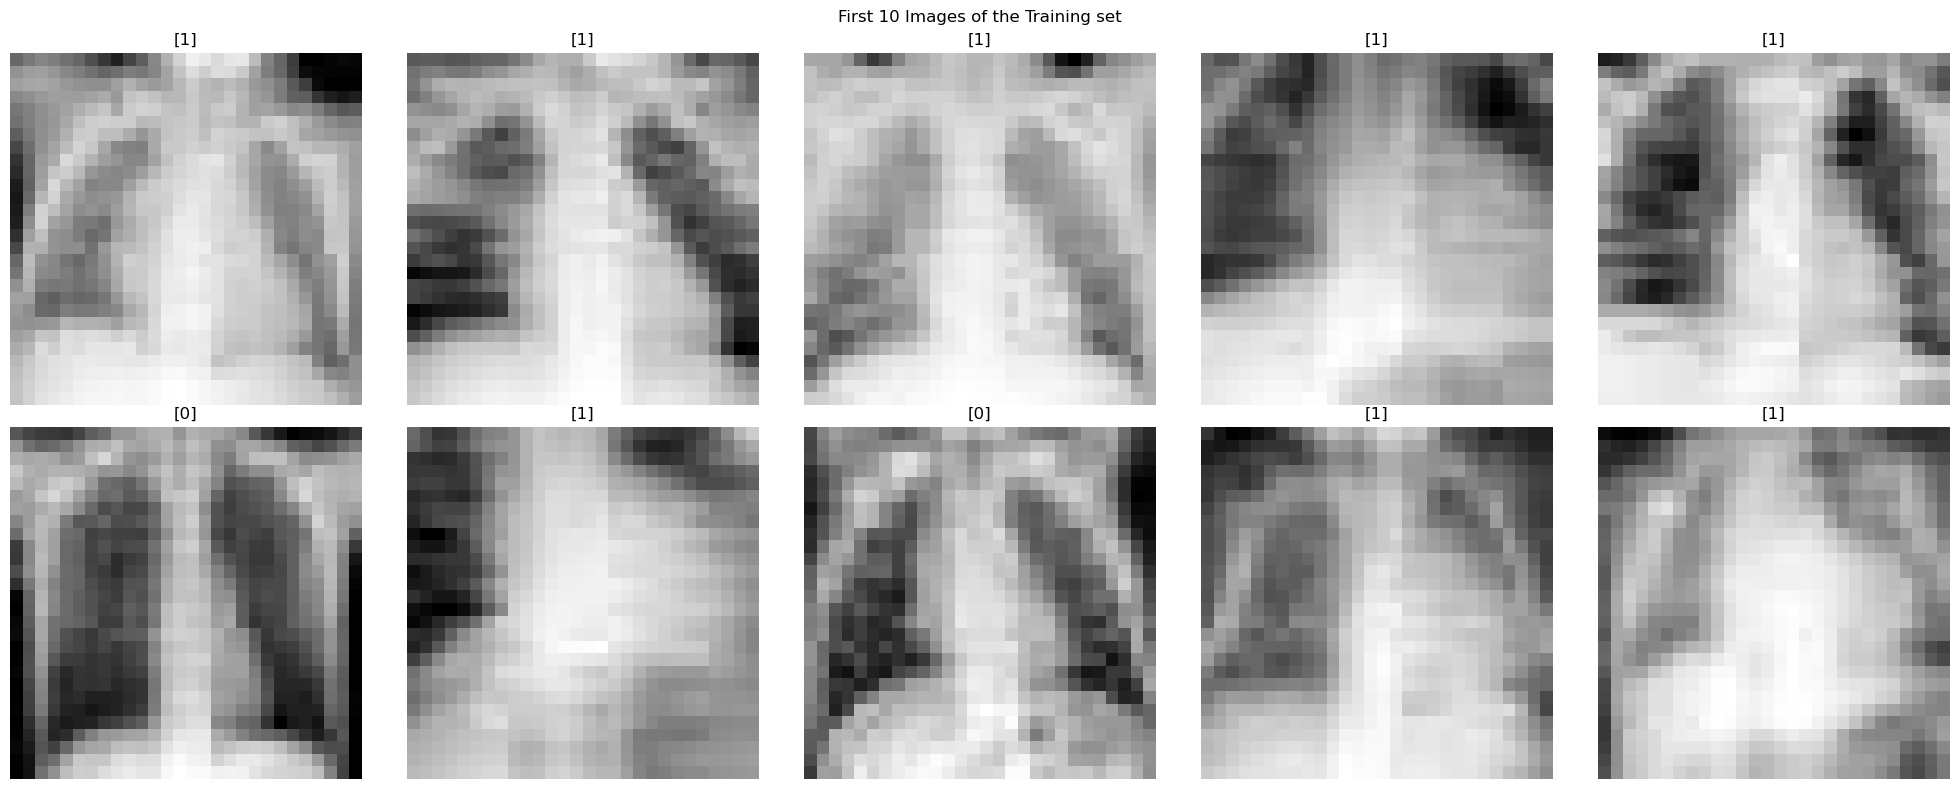

In [2]:
# Load the files for the training, testing and validation sets
train_images = np.load("../data/train_images.npy")
train_labels = np.load("../data/train_labels.npy")
test_images  = np.load("../data/test_images.npy")
test_labels  = np.load("../data/test_labels.npy")
val_images   = np.load("../data/val_images.npy")
val_labels   = np.load("../data/val_labels.npy")

# Print the shapes of the data
print("Train - images:", train_images.shape, " labels:", train_labels.shape)
print("Test  - images:", test_images.shape, " labels:", test_labels.shape)
print("Val   - images:", val_images.shape, " labels:", val_labels.shape)

# Check the unique labels in all sets
unique_train, counts_train = np.unique(train_labels, return_counts=True)
unique_test, counts_test   = np.unique(test_labels, return_counts=True)
unique_val, counts_val     = np.unique(val_labels, return_counts=True)

print("\nDistribution of labels in each set:")
print("Training set   - Normal: {}, Pneumonia: {}".format(counts_train[0], counts_train[1]))
print("Testing set    - Normal: {}, Pneumonia: {}".format(counts_test[0], counts_test[1]))
print("Validation set - Normal: {}, Pneumonia: {}".format(counts_val[0], counts_val[1]))

# Plot 10 images in a 2x5 grid from the training setRafaela
num_images = 10
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        idx = i * 5 + j
        axs[i,j].imshow(train_images[idx], cmap='gray')
        axs[i,j].set_title(train_labels[idx])
        axs[i,j].axis('off')
plt.suptitle(f"First {num_images} Images of the Training set")
plt.tight_layout()
plt.show()

# Class Distribution

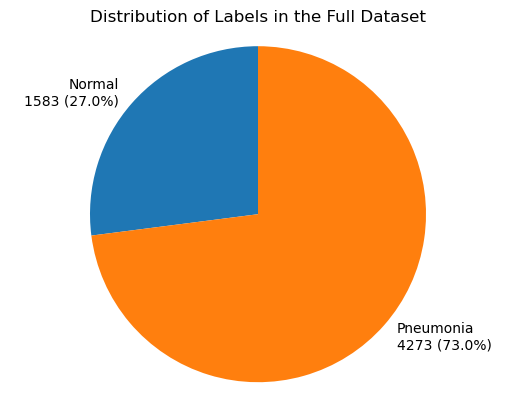


Distribution of labels in the full dataset:

           Count  Percentage
Label                       
Normal      1583   27.032104
Pneumonia   4273   72.967896


In [3]:
# Pie chart with the distribution of labels overall
labels = ['Normal', 'Pneumonia']
sizes = [counts_train[0] + counts_test[0] + counts_val[0], counts_train[1] + counts_test[1] + counts_val[1]]

# Calculate percentages and create custom labels
total = sum(sizes)
percentages = [s/total*100 for s in sizes]
labels = [f'{labels[i]}\n{sizes[i]} ({percentages[i]:.1f}%)' for i in range(len(labels))]

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='', startangle=90)
ax1.axis('equal')
plt.title("Distribution of Labels in the Full Dataset")
plt.show()

# Table with the distribution of labels in the full dataset
data = {'Label': ['Normal', 'Pneumonia'], 
        'Count': [sizes[0], sizes[1]], 
        'Percentage': [percentages[0], percentages[1]]}
df = pd.DataFrame(data)
df.set_index('Label', inplace=True)
print("\nDistribution of labels in the full dataset:\n")
print(df)

# Data Splitting
- The data was already pre-split by the authors, but it is still useful to verify the amount of examples in each set.

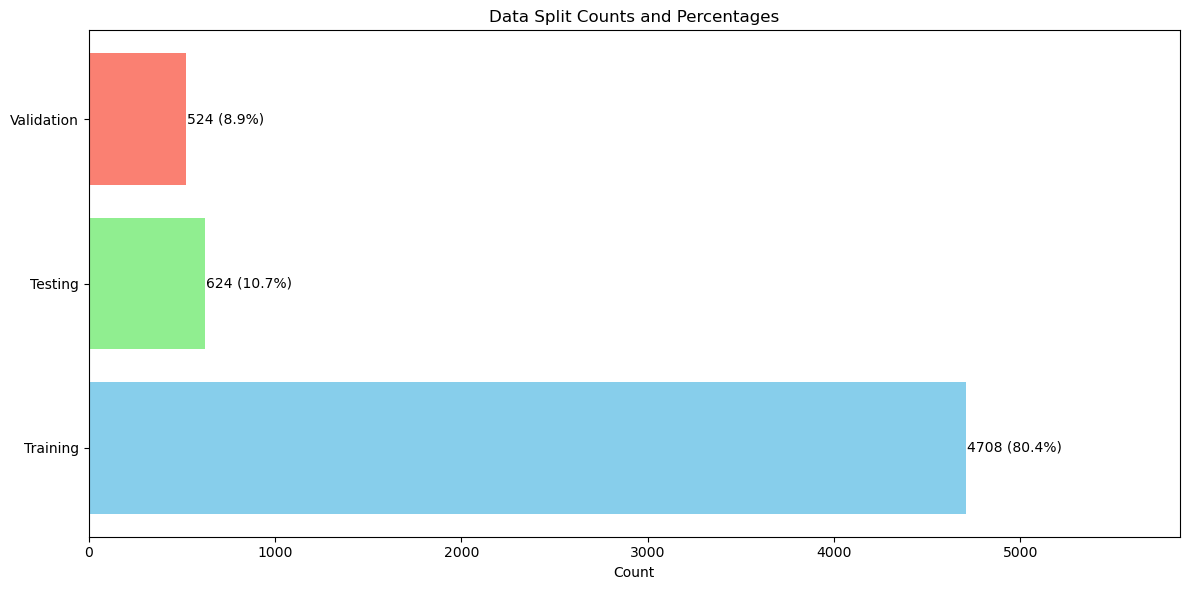


Data Split Counts and Percentages:

            Count Percentage
Set                         
Training     4708      80.4%
Testing       624      10.7%
Validation    524       8.9%


In [4]:
# Calculate totals for each dataset
total_train = counts_train[0] + counts_train[1]
total_test  = counts_test[0] + counts_test[1]
total_val   = counts_val[0] + counts_val[1]
total_all   = total_train + total_test + total_val

# Labels and counts for each split
split_labels = ['Training', 'Testing', 'Validation']
split_counts = [total_train, total_test, total_val]

colors = ['skyblue', 'lightgreen', 'salmon']

# Horizontal Bar Chart (Sidebar) for Data Split
plt.figure(figsize=(12,6))
bars = plt.barh(split_labels, split_counts, color=colors)
for bar, count in zip(bars, split_counts):
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/total_all*100:.1f}%)', va='center', fontsize=10)
plt.xlim(0, total_all)
plt.title('Data Split Counts and Percentages')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Table with the data split counts and percentages
data = {'Set': split_labels,
        'Count': split_counts,
        'Percentage': [f'{c/total_all*100:.1f}%' for c in split_counts]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nData Split Counts and Percentages:\n")
print(df)

# Class Distribution across Splits (Sets)

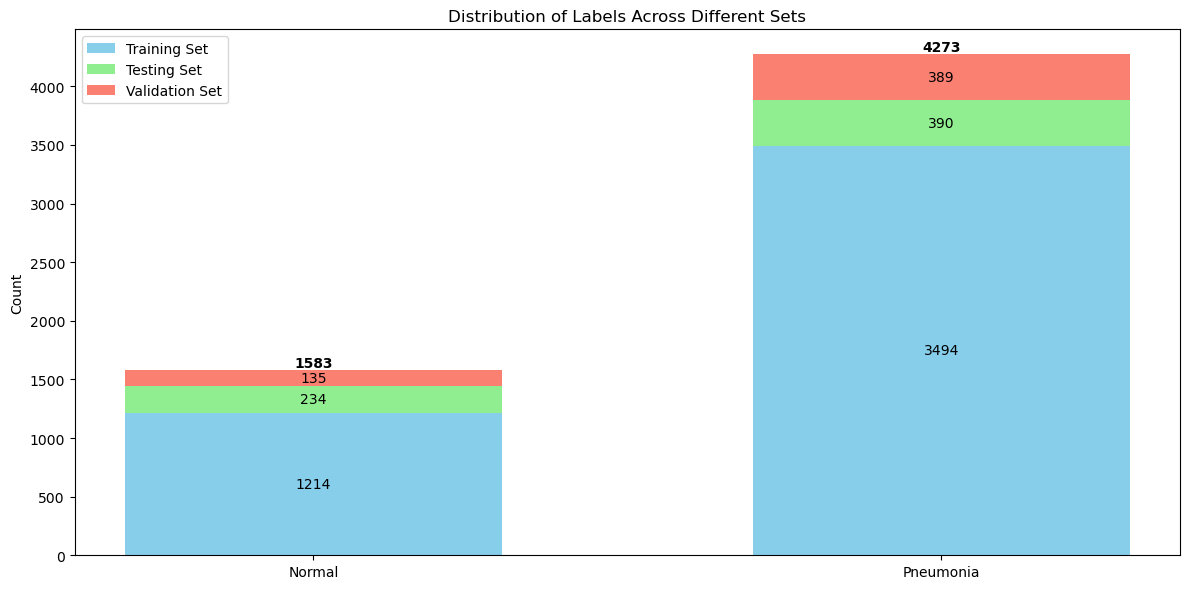


Distribution of labels accross different sets:

            Normal  Pneumonia
Set                          
Training      1214       3494
Testing        234        390
Validation     135        389
TOTAL         1583       4273


In [5]:
# Create stacked bar chart with individual segment annotations
width = 0.6
labels = ['Normal', 'Pneumonia']

plt.figure(figsize=(12, 6))

# Calculate totals for each label
total_normal = counts_train[0] + counts_test[0] + counts_val[0]
total_pneumonia = counts_train[1] + counts_test[1] + counts_val[1]

# Plot stacked bars for each set
plt.bar(labels, [counts_train[0], counts_train[1]], width,
        label='Training Set', color='skyblue')
plt.bar(labels, [counts_test[0], counts_test[1]], width,
        bottom=[counts_train[0], counts_train[1]],
        label='Testing Set', color='lightgreen')
plt.bar(labels, [counts_val[0], counts_val[1]], width,
        bottom=[counts_train[0] + counts_test[0], counts_train[1] + counts_test[1]],
        label='Validation Set', color='salmon')

# Annotate each segment with its value
for i, label in enumerate(labels):
    # Training set annotation
    train_val = counts_train[i]
    plt.text(i, train_val/2, str(train_val),
            ha='center', va='center', color='black')
    
    # Testing set annotation
    test_val = counts_test[i]
    plt.text(i, counts_train[i] + test_val/2, str(test_val),
            ha='center', va='center', color='black')
    
    # Validation set annotation
    val_val = counts_val[i]
    plt.text(i, counts_train[i] + counts_test[i] + val_val/2, str(val_val),
            ha='center', va='center', color='black')
    
    # Add the total on top of the bar
    total = total_normal if i == 0 else total_pneumonia
    plt.text(i, total, str(total), ha='center', va='bottom', fontweight='bold')

plt.ylabel('Count')
plt.title('Distribution of Labels Across Different Sets')
plt.legend()
plt.tight_layout()
plt.show()

# Table with the distribution of labels accross different sets
data = {'Set': ['Training', 'Testing', 'Validation', 'TOTAL'],
        'Normal': [counts_train[0], counts_test[0], counts_val[0], total_normal],
        'Pneumonia': [counts_train[1], counts_test[1], counts_val[1], total_pneumonia]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nDistribution of labels accross different sets:\n")
print(df)

# Data Augmentation

I0000 00:00:1742993459.176931   80749 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


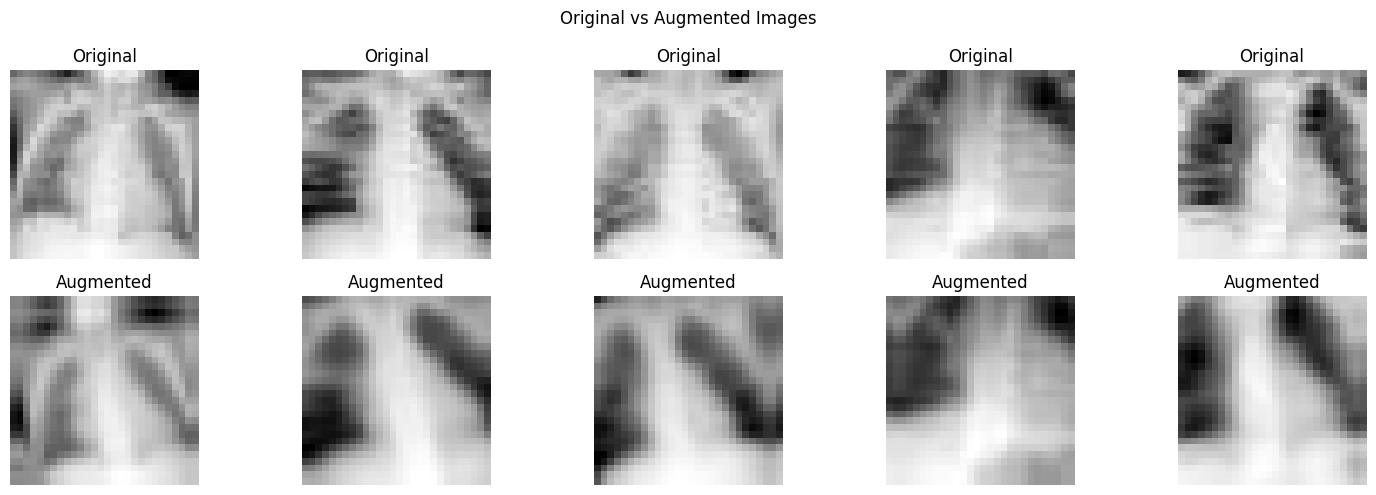

Augmented batch shape: (32, 28, 28, 1)
Augmented labels shape: (32, 2)


2025-03-26 12:51:05.014906: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Preprocess images (reshape and normalize)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
train_images = train_images.astype('float32') / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels, 2)

# Create the augmentation pipeline
augmentation_pipeline = create_augmentation_pipeline()

# Visualize augmented images
plt.figure(figsize=(15, 5))
for i in range(5):
    # Select an original image
    original_image = train_images[i]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(original_image.squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    # Apply augmentation multiple times to show variations
    augmented_image = augmentation_pipeline(tf.expand_dims(original_image, 0), training=True)
    plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
    plt.title('Augmented')
    plt.axis('off')

plt.suptitle('Original vs Augmented Images')
plt.tight_layout()
plt.show()

# If you want to see how the augmented dataset looks when batched
augmented_dataset = apply_augmentation(train_images, train_labels, batch_size=32)

# Iterate through the augmented dataset to verify
for images, labels in augmented_dataset.take(1):
    print("Augmented batch shape:", images.shape)
    print("Augmented labels shape:", labels.shape)